###Question 2 - Principles of Data Science CS5530
Morgan Sansone

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Ingest

In [27]:
# load data

# create dataframe
df_students = pd.read_csv('StudentsPerformance.csv')

print(df_students.head(5)) # print the first 5 values in the dataframe

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


##Preprocessing

In [28]:
# handle the missing values
print(df_students.isna().sum()) # check
df_students.fillna(df_students.mean(numeric_only=True), inplace=True) # replace numerical NaN with mean

# create overall_avg column for V3 (math+reading+writing)/3
df_students['overall_avg'] = df_students[['math score', 'reading score', 'writing score']].mean(axis=1)

# save cleaned data
df_students.to_csv('student_performance_cleaned.csv', index=False)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


##Analysis

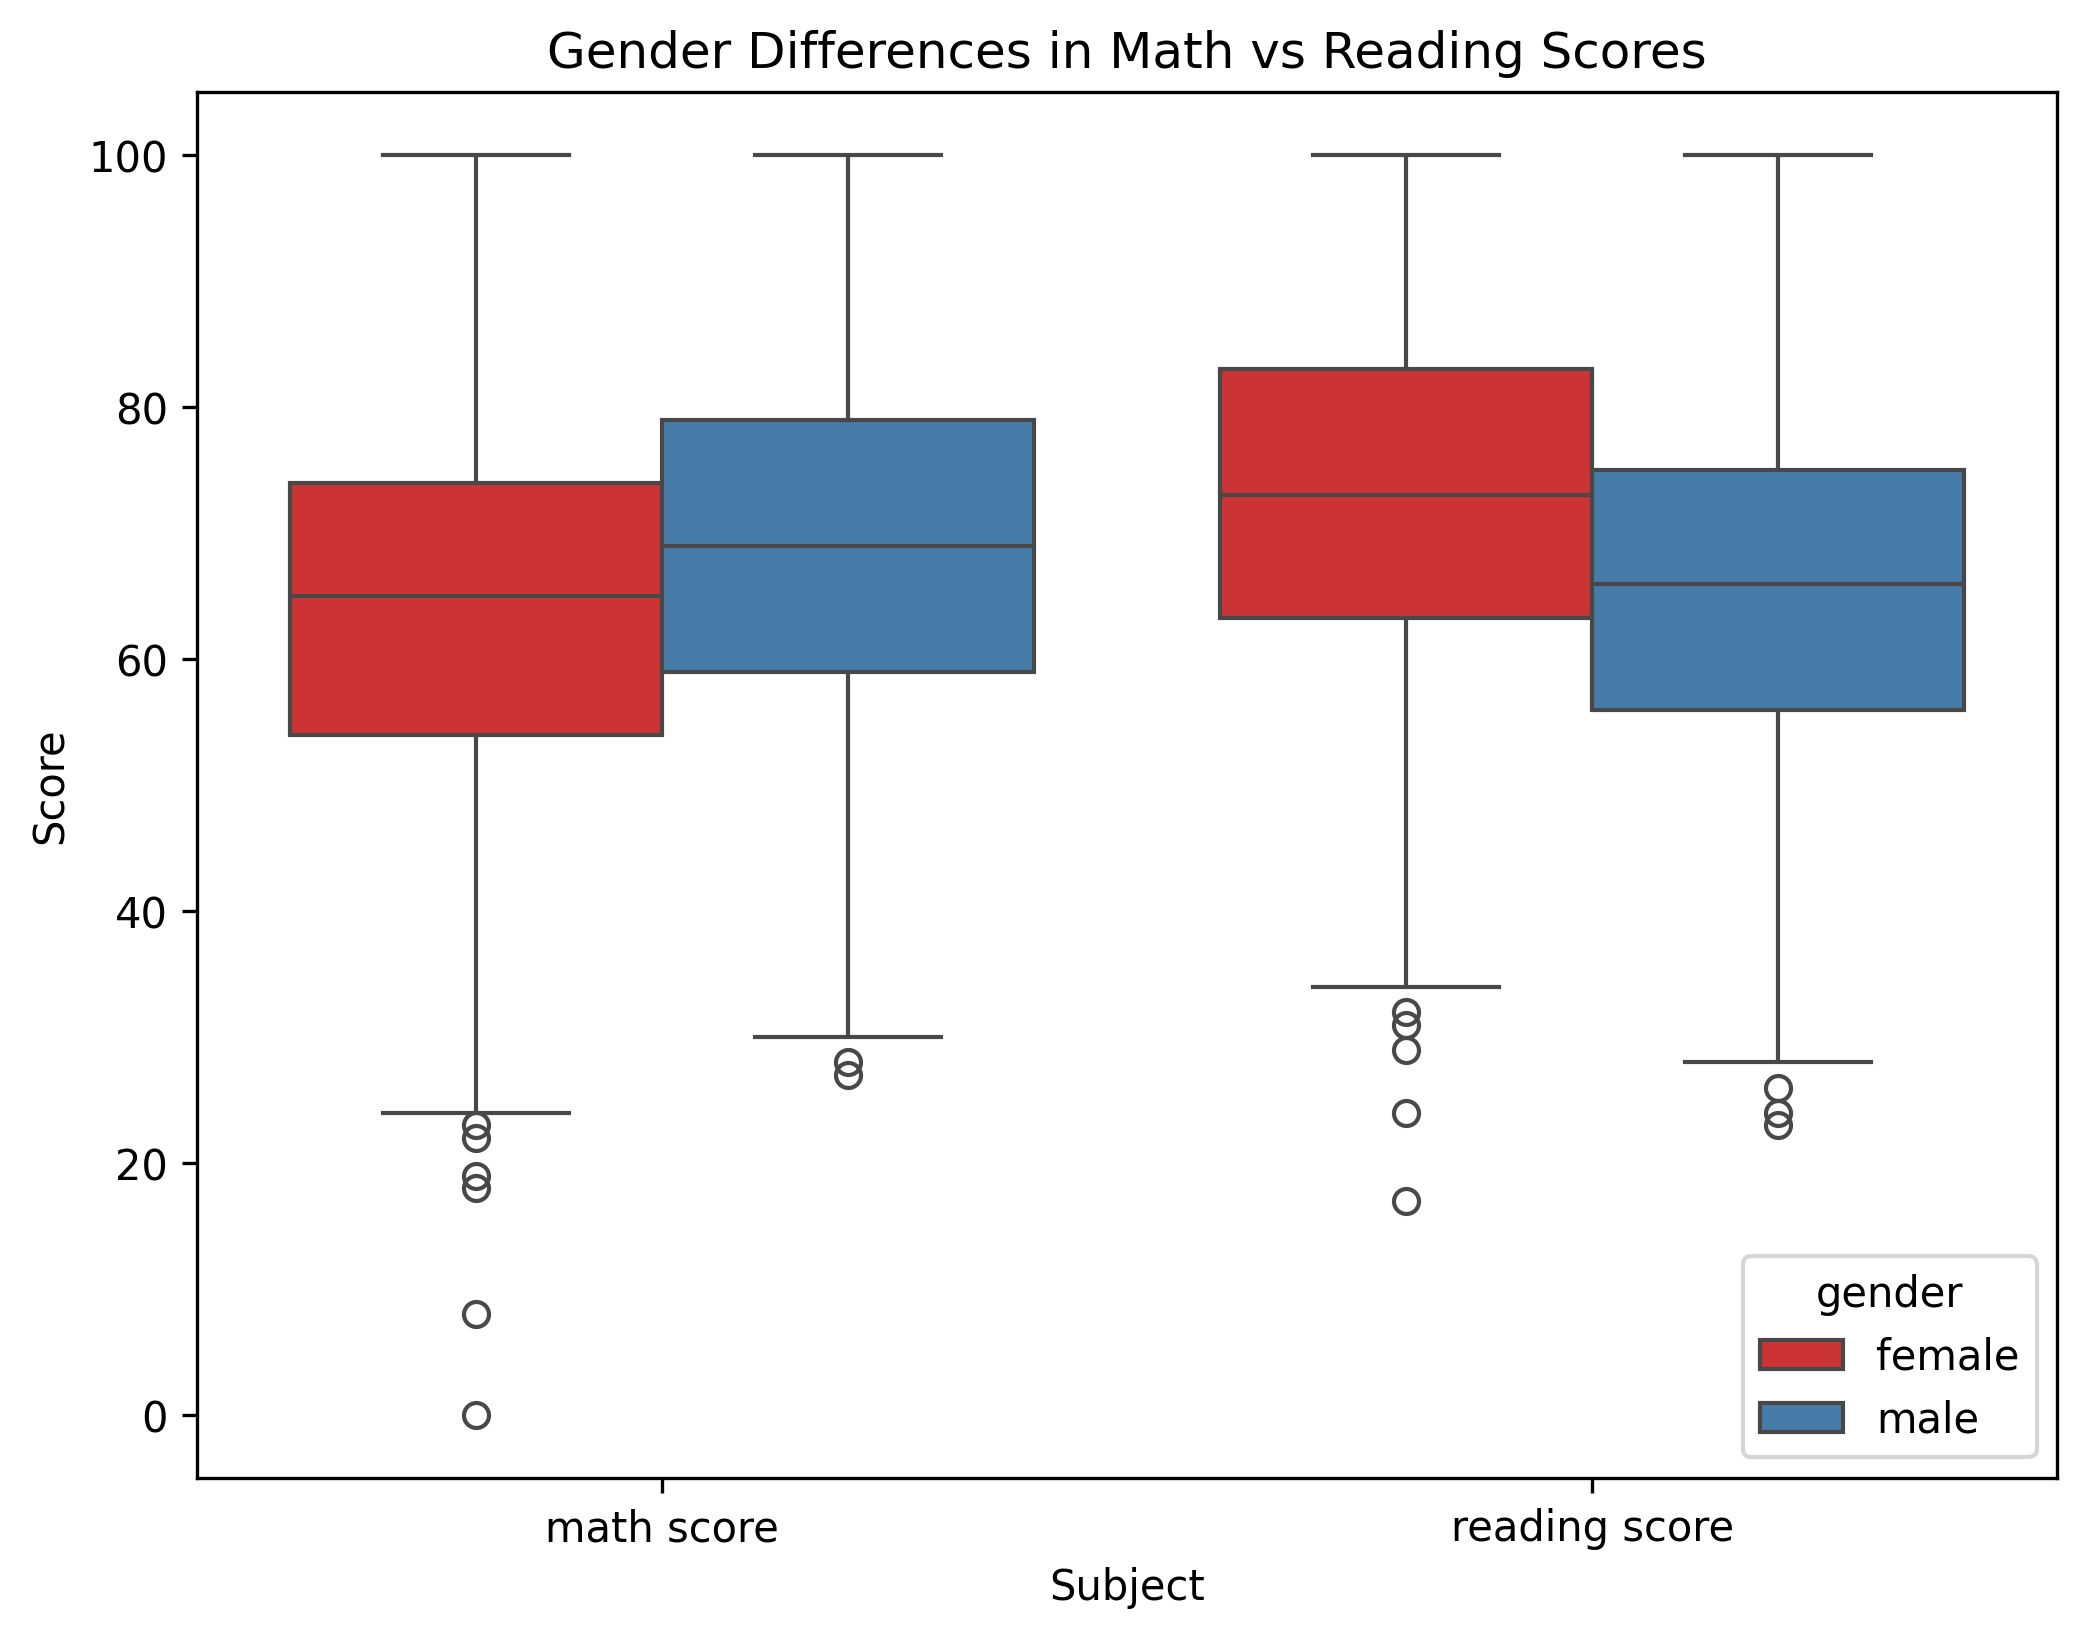

In [29]:
# V1 - Are there gender differences in math vs reading?
plt.figure(figsize=(8, 6), dpi=300) # 800 x 6000 w dpi of 300

# melt data to new dataframe
v1_df = df_students.melt(id_vars='gender', value_vars=['math score', 'reading score'],
                           var_name='Subject', value_name='Score')

# boxplot
sns.boxplot(x='Subject', y='Score', hue='gender', data=v1_df, palette='Set1') # added colors

# title & labels
plt.title('Gender Differences in Math vs Reading Scores')
plt.xlabel('Subject')
plt.ylabel('Score')

# saving figure to png & displaying
plt.savefig('v1_gender_boxplot.png')
plt.show()

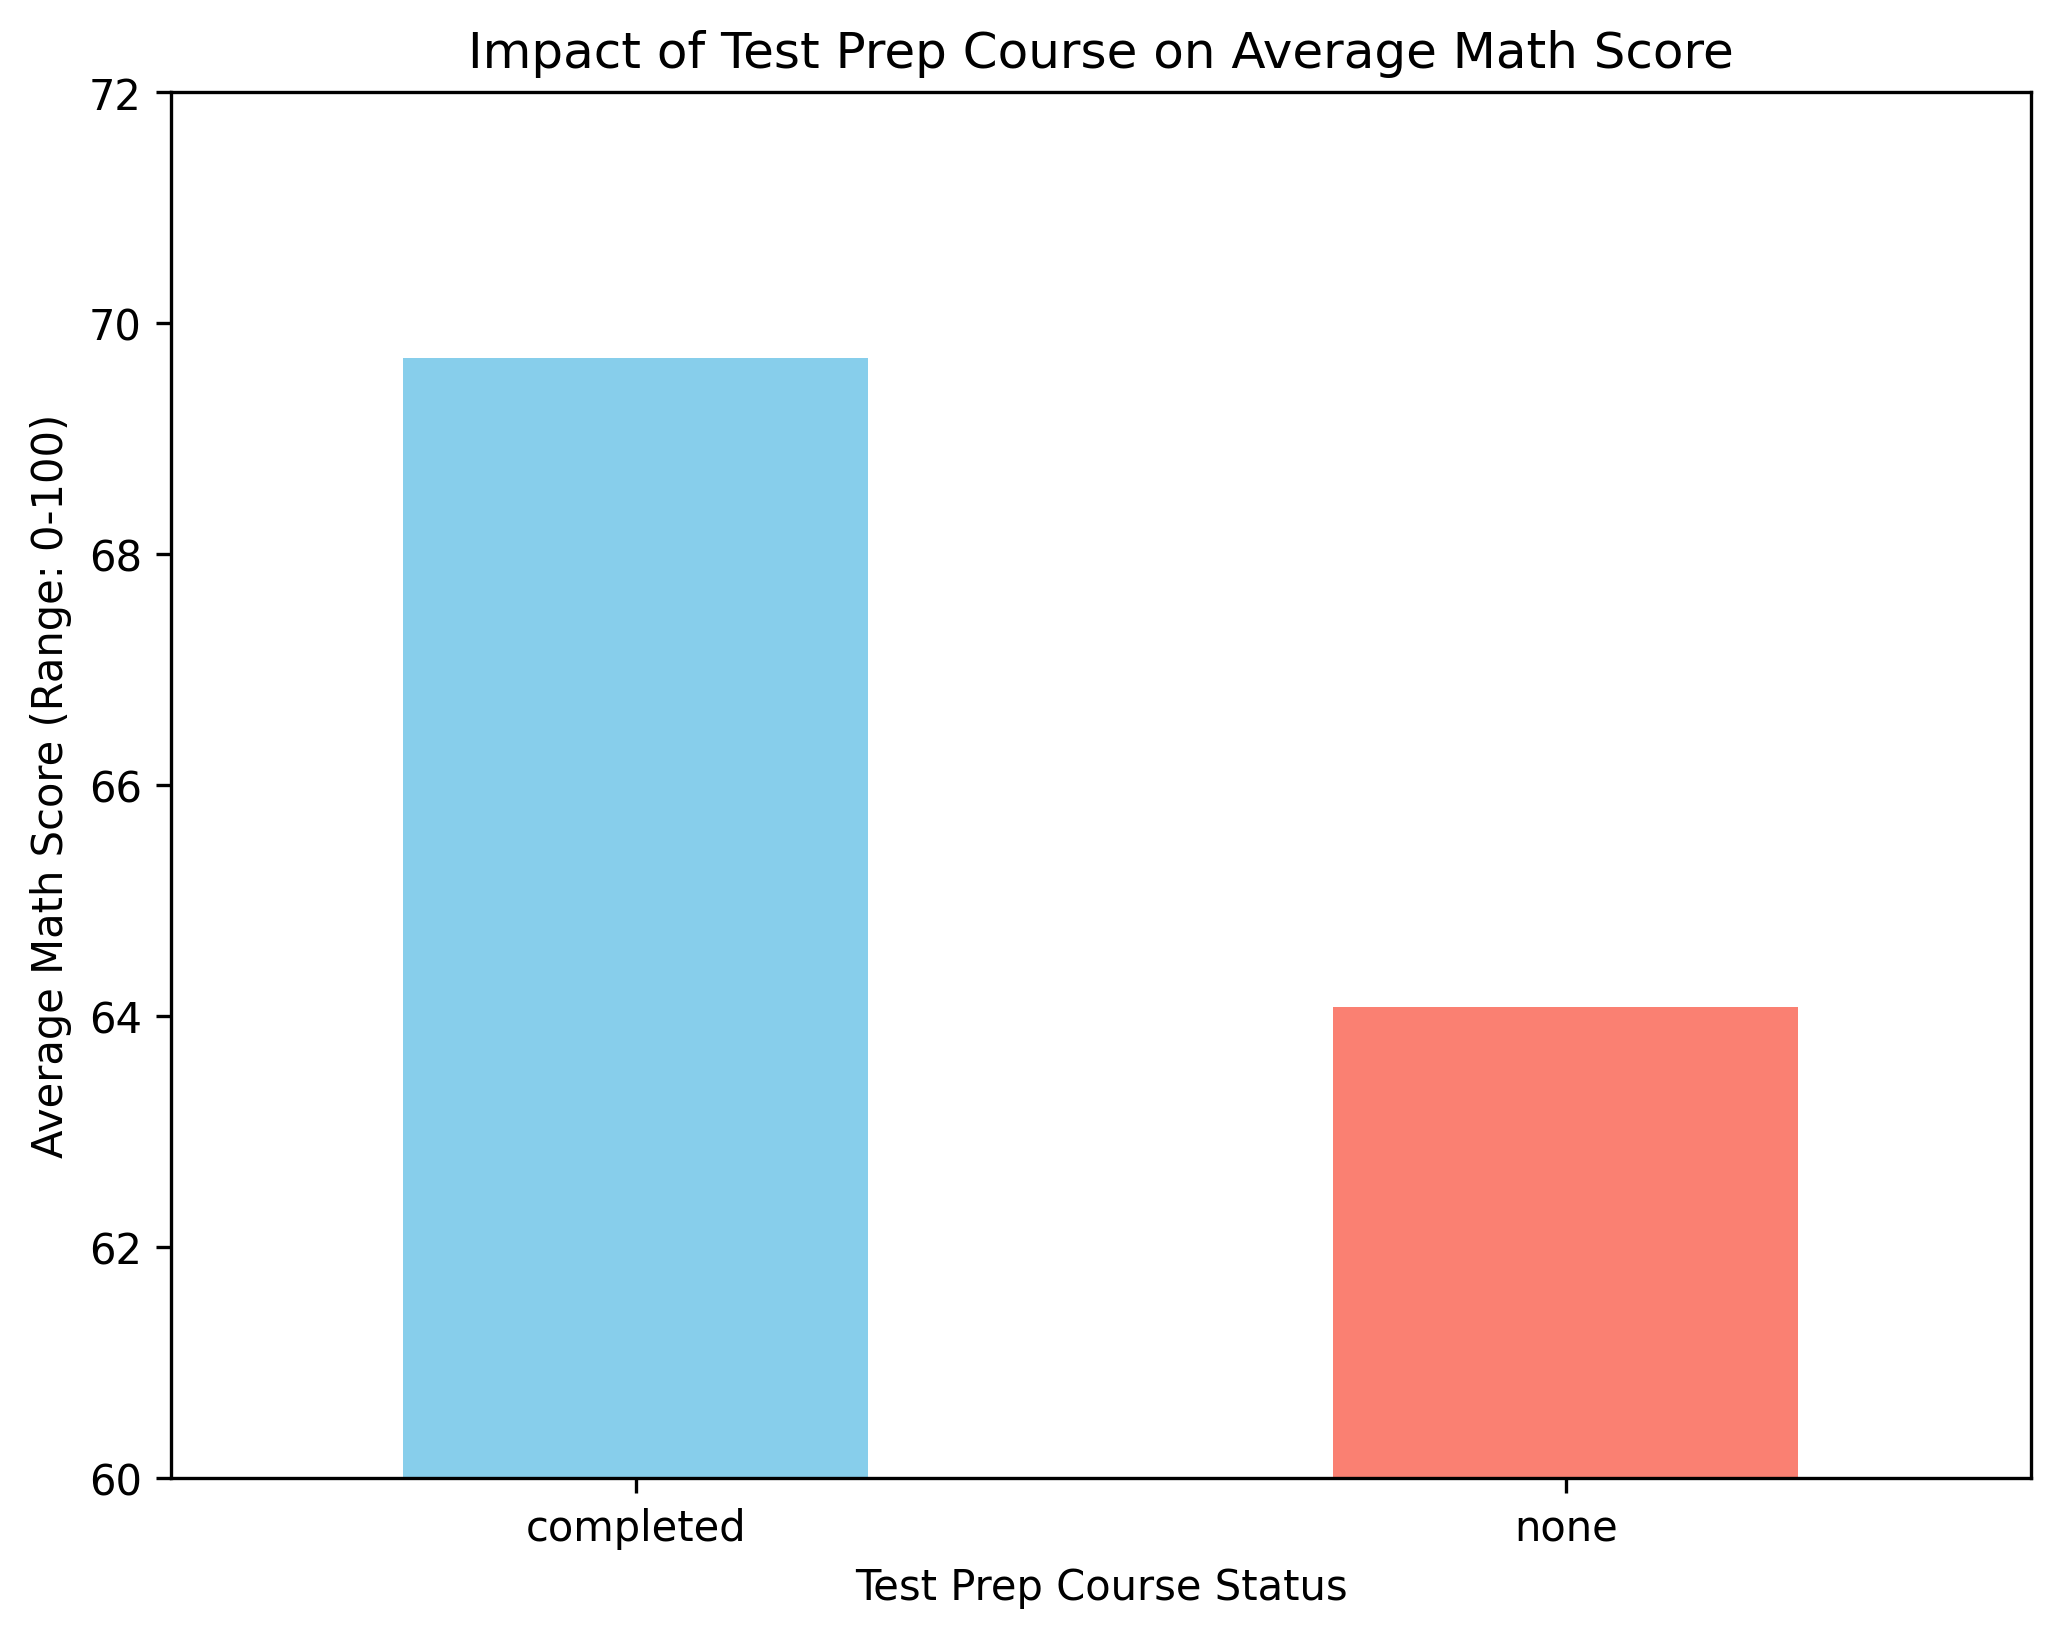

In [30]:
# V2 - Do students who completed test prep score higher in math?
plt.figure(figsize=(8, 6), dpi=300) # 800 x 6000 w dpi of 300

# calculate average math score
test_prep_avg = df_students.groupby('test preparation course')['math score'].mean()

# bar chart
V2_chart = test_prep_avg.plot.bar(figsize=(8, 6), color=['skyblue', 'salmon'], rot=0)

# scale & labels
plt.ylim(60, 72) # range of 60-72
plt.yticks(np.arange(60, 73, 2)) # tick every 2

# title & labels
plt.title('Impact of Test Prep Course on Average Math Score')
plt.xlabel('Test Prep Course Status')
plt.ylabel('Average Math Score (Range: 0-100)')

# saving figure to png & displaying
plt.savefig('v2_test_prep_impact.png', dpi=300)
plt.show()

<Figure size 2400x1800 with 0 Axes>

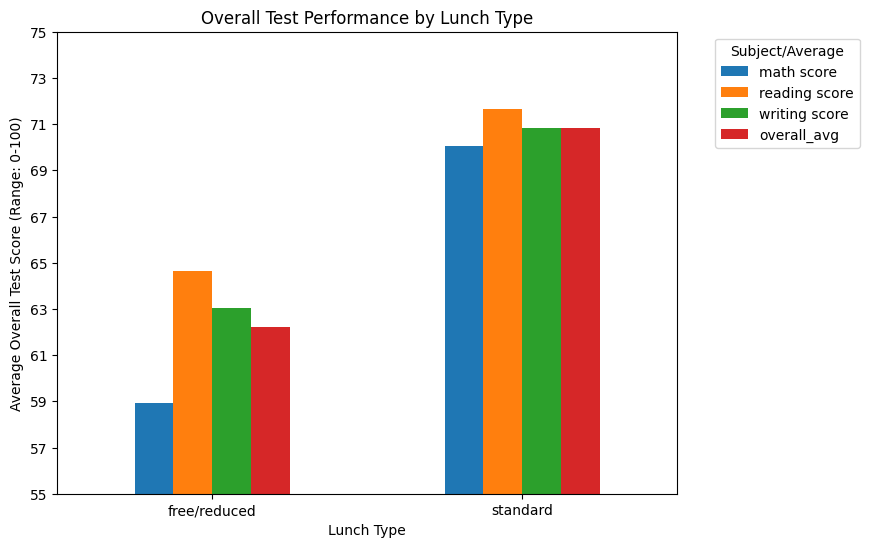

In [31]:
# V3 - Does lunch type (standard vs free/reduced) relate to outcomes?
plt.figure(figsize=(8, 6), dpi=300) # 800 x 6000 w dpi of 300

# overall avg for all 3 subjects column
df_students['overall_avg'] = df_students[['math score', 'reading score', 'writing score']].mean(axis=1)

# grouping by lunch and getting mean for all scores
lunch_comparison = df_students.groupby('lunch')[['math score', 'reading score', 'writing score', 'overall_avg']].mean()

# grouped bar chart
V3_plot = lunch_comparison.plot.bar(figsize=(8, 6), rot=0)

# scale & labels
plt.ylim(55, 75) # range of 50-80
plt.yticks(np.arange(55, 76, 2)) # tick every 5

plt.title('Overall Test Performance by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Overall Test Score (Range: 0-100)')
plt.legend(title='Subject/Average', bbox_to_anchor=(1.05, 1), loc='upper left')

# saving figure to png & displaying
plt.savefig('v3_lunch_type_bar.png', dpi=300, bbox_inches='tight')
plt.show()

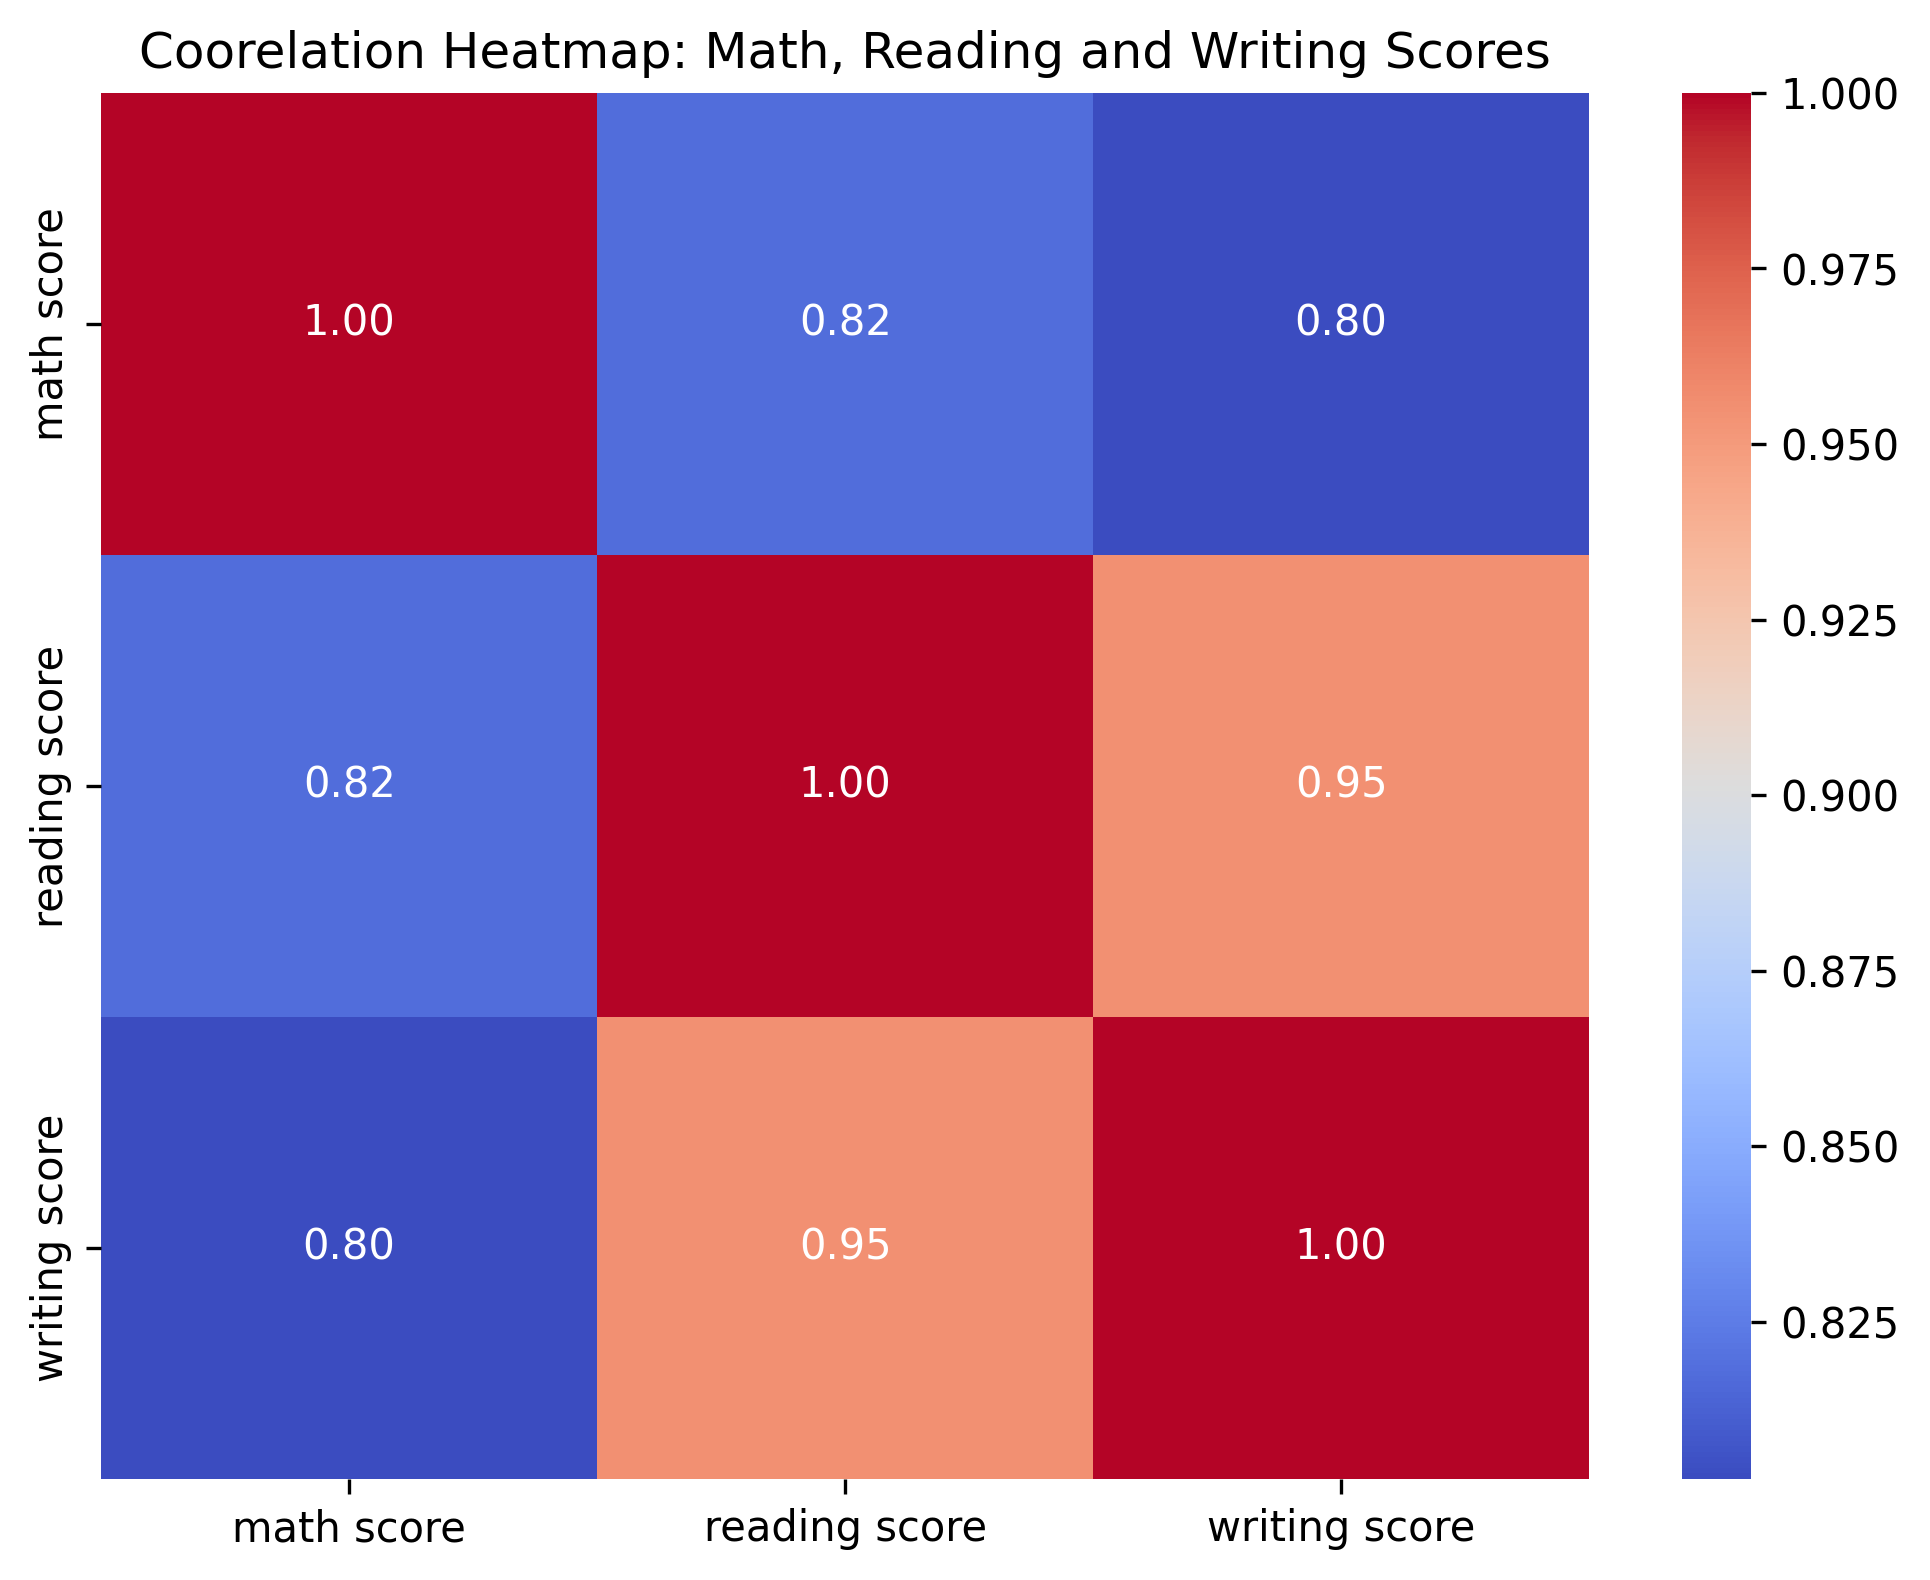

In [32]:
# V4 - How strongly do the three subjects move together?
plt.figure(figsize=(8, 6), dpi=300) # 800 x 6000 w dpi of 300

# avg for all 3 subjects
V4_matrix = df_students[['math score', 'reading score', 'writing score']].corr()

# make heatmap
sns.heatmap(V4_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# title
plt.title('Coorelation Heatmap: Math, Reading and Writing Scores')

# saving figure to png & displaying
plt.savefig('v4_subject_correlation.png', dpi=300)
plt.show()

<Figure size 2400x1800 with 0 Axes>

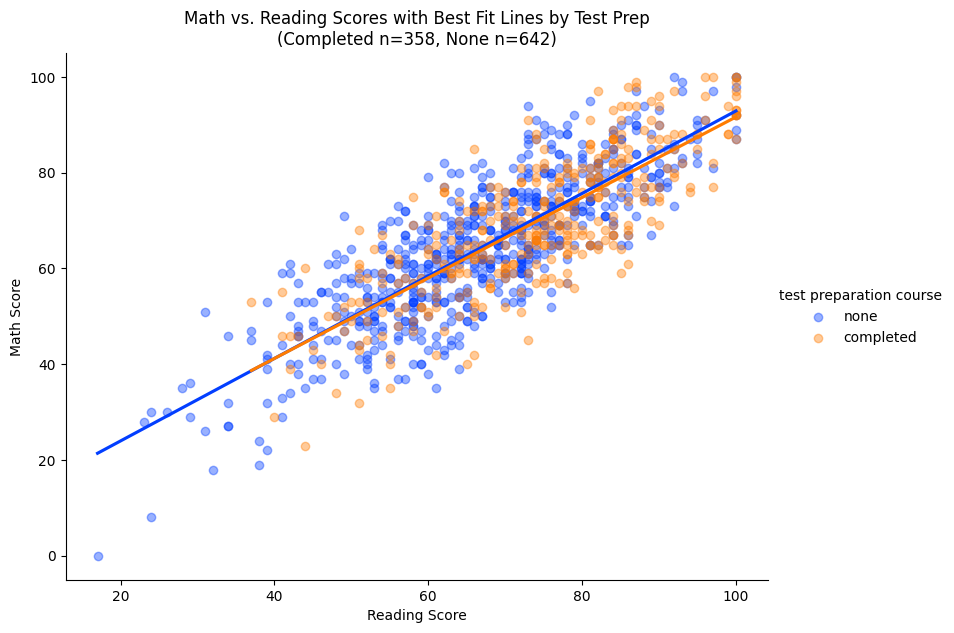

In [33]:
# V5 - How strongly are math and reading scores associated, and do students who
# completed the test‑preparation course have a different slope in the math–reading
# relationship than those who did not?

plt.figure(figsize=(8, 6), dpi=300) # 800 x 6000 w dpi of 300

# calculate the count for each group
n_none = len(df_students[df_students['test preparation course'] == 'none'])
n_comp = len(df_students[df_students['test preparation course'] == 'completed'])

# scatterplot with best fit lines
V5_scatter = sns.lmplot(x='reading score', y='math score', hue='test preparation course',
           data=df_students, palette='bright', ci=None,
               height=6, aspect=1.33, scatter_kws={'alpha':0.4})

# title & labels
plt.title(f'Math vs. Reading Scores with Best Fit Lines by Test Prep\n(Completed n={n_comp}, None n={n_none})')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')

# saving figure to png & displaying
plt.savefig('v5_math_reading_scatter.png', dpi=300, bbox_inches='tight')
plt.show()